In [1]:
import pandas as pd
import numpy as np

In [2]:
event = pd.read_csv('../data/raw/holidays_events.csv')

In [3]:
event.isnull().sum()

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

In [4]:
oil = pd.read_csv('../data/raw/oil.csv')
oil.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

In [5]:
items = pd.read_csv('../data/raw/items.csv')
items.isnull().sum()

item_nbr      0
family        0
class         0
perishable    0
dtype: int64

In [6]:
submission = pd.read_csv('../data/raw/sample_submission.csv')
submission.isnull().sum()

id            0
unit_sales    0
dtype: int64

In [7]:
stores = pd.read_csv('../data/raw/stores.csv')
stores.isnull().sum()

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

In [8]:
transaction = pd.read_csv(r'E:\nic\SIC-AI-PROJECT-\data\raw\transactions.csv')
transaction.isnull().sum()

date            0
store_nbr       0
transactions    0
dtype: int64

In [9]:
train = pd.read_parquet('../data/processed/train_merged.parquet')

In [10]:
train.head()

,store_nbr,family,date,unit_sales,onpromotion,oil_price,is_earthquake_period,holiday_type,city,state,type,cluster,perishable,transactions_lag1,target
0,1,AUTOMOTIVE,2016-01-02,7.0,False,36.81,False,Normal Day,Quito,Pichincha,D,13,0,NaN,7.0
1,1,AUTOMOTIVE,2016-01-03,1.0,False,36.81,False,Normal Day,Quito,Pichincha,D,13,0,NaN,1.0
2,1,AUTOMOTIVE,2016-01-04,8.0,False,36.81,False,Normal Day,Quito,Pichincha,D,13,0,2025.0,8.0
3,1,AUTOMOTIVE,2016-01-05,7.0,False,35.97,False,Normal Day,Quito,Pichincha,D,13,0,10.0,7.0
4,1,AUTOMOTIVE,2016-01-06,9.0,False,33.97,False,Normal Day,Quito,Pichincha,D,13,0,1840.0,9.0


In [11]:
train.columns

Index(['store_nbr', 'family', 'date', 'unit_sales', 'onpromotion', 'oil_price',
       'is_earthquake_period', 'holiday_type', 'city', 'state', 'type',
       'cluster', 'perishable', 'transactions_lag1', 'target'],
      dtype='object')

store_nbr: Mã số định danh cửa hàng (Store Number).

family: Danh mục/Dòng sản phẩm (ví dụ: GROCERY, BEVERAGES, PRODUCE...).

date: Ngày ghi nhận dữ liệu giao dịch.

unit_sales: Tổng số lượng sản phẩm bán ra thực tế trong ngày.

onpromotion: Cột đánh dấu trạng thái khuyến mãi (1: đang có khuyến mãi, 0: không có).

oil_price: Giá dầu thô trong ngày (yếu tố kinh tế vĩ mô ảnh hưởng đến sức mua tại Ecuador).

is_earthquake_period: Cột biến phụ (Flag feature) đánh dấu giai đoạn chịu ảnh hưởng bởi trận động đất lớn tại Ecuador năm 2016 (1: giai đoạn động đất, 0: bình thường).

holiday_type: Phân loại ngày lễ/sự kiện trong ngày (ví dụ: Holiday, Event, Transfer, Normal).

city: Thành phố nơi đặt cửa hàng.

state: Bang/Tỉnh nơi đặt cửa hàng.

type: Loại quy mô cửa hàng (phân loại từ A đến E).

cluster: Mã nhóm các cửa hàng có đặc điểm doanh số/hành vi tiêu dùng tương đồng.

transactions_lag1: Tổng số lượt giao dịch (hóa đơn) của cửa hàng đó ở 1 ngày trước đó (Lag 1 feature được tạo ra để dự báo).

target: Biến mục tiêu để đưa vào mô hình huấn luyện (thường là np.log1p(unit_sales) đã qua xử lý logarit để tính điểm NWRMSLE).

In [12]:
train.isnull().sum()

store_nbr                  0
family                     0
date                       0
unit_sales                 0
onpromotion                0
oil_price                  0
is_earthquake_period       0
holiday_type               0
city                       0
state                      0
type                       0
cluster                    0
perishable                 0
transactions_lag1       3162
target                     0
dtype: int64

In [13]:
from sklearn.impute import SimpleImputer

# 1. Khởi tạo imputer với strategy='constant' và fill_value=0
imputer = SimpleImputer(strategy='constant', fill_value=0)

# 2. Transform cột dữ liệu (cần truyền dạng 2D dataframe [[...]])
train['transactions_lag1'] = imputer.fit_transform(train[['transactions_lag1']])

In [14]:
train.isnull().sum()

store_nbr               0
family                  0
date                    0
unit_sales              0
onpromotion             0
oil_price               0
is_earthquake_period    0
holiday_type            0
city                    0
state                   0
type                    0
cluster                 0
perishable              0
transactions_lag1       0
target                  0
dtype: int64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
train.describe()

,store_nbr,date,unit_sales,oil_price,cluster,perishable,transactions_lag1,target
count,874052.000000,874052,874052.000000,874052.000000,874052.000000,874052.000000,874052.000000,874052.000000
mean,27.239577,2016-10-26 06:33:13.408172032,552.427734,45.671888,8.486566,0.318282,1688.029835,552.452087
min,1.000000,2016-01-01 00:00:00,-6663.000000,26.190000,1.000000,0.000000,0.000000,0.000000
25%,13.000000,2016-05-30 00:00:00,9.000000,43.410000,4.000000,0.000000,1042.000000,9.000000
50%,27.000000,2016-10-28 00:00:00,61.221500,47.020000,8.000000,0.000000,1389.000000,61.221500
75%,41.000000,2017-03-26 00:00:00,370.499504,49.760000,13.000000,1.000000,2048.000000,370.499504
max,54.000000,2017-08-15 00:00:00,124717.000000,54.480000,17.000000,1.000000,8307.000000,124717.000000
std,15.644502,NaN,1428.538208,6.366444,4.634879,0.465810,962.864967,1428.492310


In [17]:
# train_or = pd.read_csv('../data/raw/train.csv')
# print(len(train), len(train_or))  # phải bằng nhau nếu join đúng

In [18]:
train[train['unit_sales'] < -1000]

,store_nbr,family,date,unit_sales,onpromotion,oil_price,is_earthquake_period,holiday_type,city,state,type,cluster,perishable,transactions_lag1,target
30339,2,PERSONAL CARE,2016-05-07,-1498.000000,True,44.58,False,Additional,Quito,Pichincha,D,13,0,2048.0,0.0
135529,8,PERSONAL CARE,2016-04-21,-2947.000000,True,43.18,True,Event,Quito,Pichincha,D,8,0,3160.0,0.0
467376,29,"LIQUOR,WINE,BEER",2016-05-16,-1993.000000,False,47.72,True,Event,Guayaquil,Guayas,E,10,0,1400.0,0.0
602414,38,FROZEN FOODS,2016-12-20,-2078.697998,True,52.22,False,Normal Day,Loja,Loja,D,4,0,1807.0,0.0
845681,53,CLEANING,2016-05-14,-2891.000000,True,46.22,True,Event,Manta,Manabi,D,13,0,1455.0,0.0
853122,53,LINGERIE,2016-05-14,-1381.000000,True,46.22,True,Event,Manta,Manabi,D,13,0,1455.0,0.0
855416,53,PERSONAL CARE,2016-05-14,-6663.000000,True,46.22,True,Event,Manta,Manabi,D,13,0,1455.0,0.0


In [19]:
neg_extreme = train[train['unit_sales'] < -1000]
cluster_check = neg_extreme.groupby(['store_nbr', 'date']).size().sort_values(ascending=False)
print(cluster_check.head(10))


store_nbr  date      
53         2016-05-14    3
2          2016-05-07    1
8          2016-04-21    1
29         2016-05-16    1
38         2016-12-20    1
dtype: int64


In [20]:
train['date'].dtype

dtype('<M8[ns]')

In [21]:
train.isnull().sum()

store_nbr               0
family                  0
date                    0
unit_sales              0
onpromotion             0
oil_price               0
is_earthquake_period    0
holiday_type            0
city                    0
state                   0
type                    0
cluster                 0
perishable              0
transactions_lag1       0
target                  0
dtype: int64

In [22]:
test_original = pd.read_csv('../data/raw/test.csv')

In [23]:
test_original.head()

,id,date,store_nbr,item_nbr,onpromotion
0,125497040,2017-08-16,1,96995,False
1,125497041,2017-08-16,1,99197,False
2,125497042,2017-08-16,1,103501,False
3,125497043,2017-08-16,1,103520,False
4,125497044,2017-08-16,1,103665,False


In [24]:
test_original['date'].max()

'2017-08-31'

In [25]:
train[train['date'] == '2017-04-06']

,store_nbr,family,date,unit_sales,onpromotion,oil_price,is_earthquake_period,holiday_type,city,state,type,cluster,perishable,transactions_lag1,target
432,1,AUTOMOTIVE,2017-04-06,10.000000,False,51.69,False,Normal Day,Quito,Pichincha,D,13,0,1930.0,10.000000
970,1,BEAUTY,2017-04-06,5.000000,True,51.69,False,Normal Day,Quito,Pichincha,D,13,0,1930.0,5.000000
1554,1,BEVERAGES,2017-04-06,2164.000000,True,51.69,False,Normal Day,Quito,Pichincha,D,13,0,1930.0,2164.000000
1779,1,BOOKS,2017-04-06,1.000000,False,51.69,False,Normal Day,Quito,Pichincha,D,13,0,1930.0,1.000000
2272,1,BREAD/BAKERY,2017-04-06,376.694000,True,51.69,False,Normal Day,Quito,Pichincha,D,13,1,1930.0,376.694000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872211,54,POULTRY,2017-04-06,57.378998,False,51.69,False,Normal Day,El Carmen,Manabi,C,3,1,708.0,57.378998
872801,54,PREPARED FOODS,2017-04-06,54.000000,False,51.69,False,Normal Day,El Carmen,Manabi,C,3,1,708.0,54.000000
873391,54,PRODUCE,2017-04-06,448.028015,True,51.69,False,Normal Day,El Carmen,Manabi,C,3,1,708.0,448.028015
873624,54,SCHOOL AND OFFICE SUPPLIES,2017-04-06,14.000000,False,51.69,False,Normal Day,El Carmen,Manabi,C,3,0,708.0,14.000000


In [26]:
train[train['date'] == '2017-04-06'].groupby('store_nbr')['unit_sales'].sum()

store_nbr
1     10487.067383
2     12824.755859
3     30905.527344
4     10573.159180
5      8273.576172
6     14424.412109
7     17922.724609
8     19310.064453
9     17439.607422
10     6243.805176
11    20735.689453
12     8433.273438
13     6174.000977
14     7273.999023
15     7603.051758
16     7559.873047
17    13441.522461
18     9568.652344
19     7531.389160
20    14598.644531
21    11034.661133
22     6383.948242
23     6973.317871
24    15576.812500
25     8175.049805
26     3418.012939
27    10202.733398
28    13749.676758
29    11676.460938
30     2964.580078
31    11683.673828
32     7883.900879
33     7095.188965
34    11691.846680
35     4823.484863
36    11911.993164
37    12582.554688
38     8578.323242
39    13860.134766
40    14606.772461
41     9003.108398
42     9840.763672
43    12509.323242
44    29803.837891
45    30907.320312
46    21262.183594
47    28857.560547
48    19602.070312
49    30495.275391
50    16066.783203
51    14284.859375
53     8218.244141
54

In [27]:
day_data = train[train['date'] == '2017-04-06']

total_with_outlier = day_data['unit_sales'].sum()
total_without_outlier = day_data[day_data['unit_sales'] != -10002]['unit_sales'].sum()

print(f"Có outlier: {total_with_outlier}")
print(f"Không có outlier: {total_without_outlier}")
print(f"Chênh lệch: {total_without_outlier - total_with_outlier}")

Có outlier: 683059.625
Không có outlier: 683059.625
Chênh lệch: 0.0


# xóa hàng 45147165	

In [28]:
store32_day = train[(train['date']=='2016-12-20') & (train['store_nbr']==32)]

total_store_with = store32_day['unit_sales'].sum()
total_store_without = store32_day[store32_day['unit_sales'] != -3451.363037]['unit_sales'].sum()

print(f"Cửa hàng 32, có outlier: {total_store_with}")
print(f"Cửa hàng 32, không có: {total_store_without}")
print(f"Tỷ lệ ảnh hưởng: {-3451.363037 / total_store_without * 100:.1f}%")

Cửa hàng 32, có outlier: 5650.5419921875
Cửa hàng 32, không có: 5650.5419921875
Tỷ lệ ảnh hưởng: -61.1%


<Axes: xlabel='holiday_type', ylabel='unit_sales'>

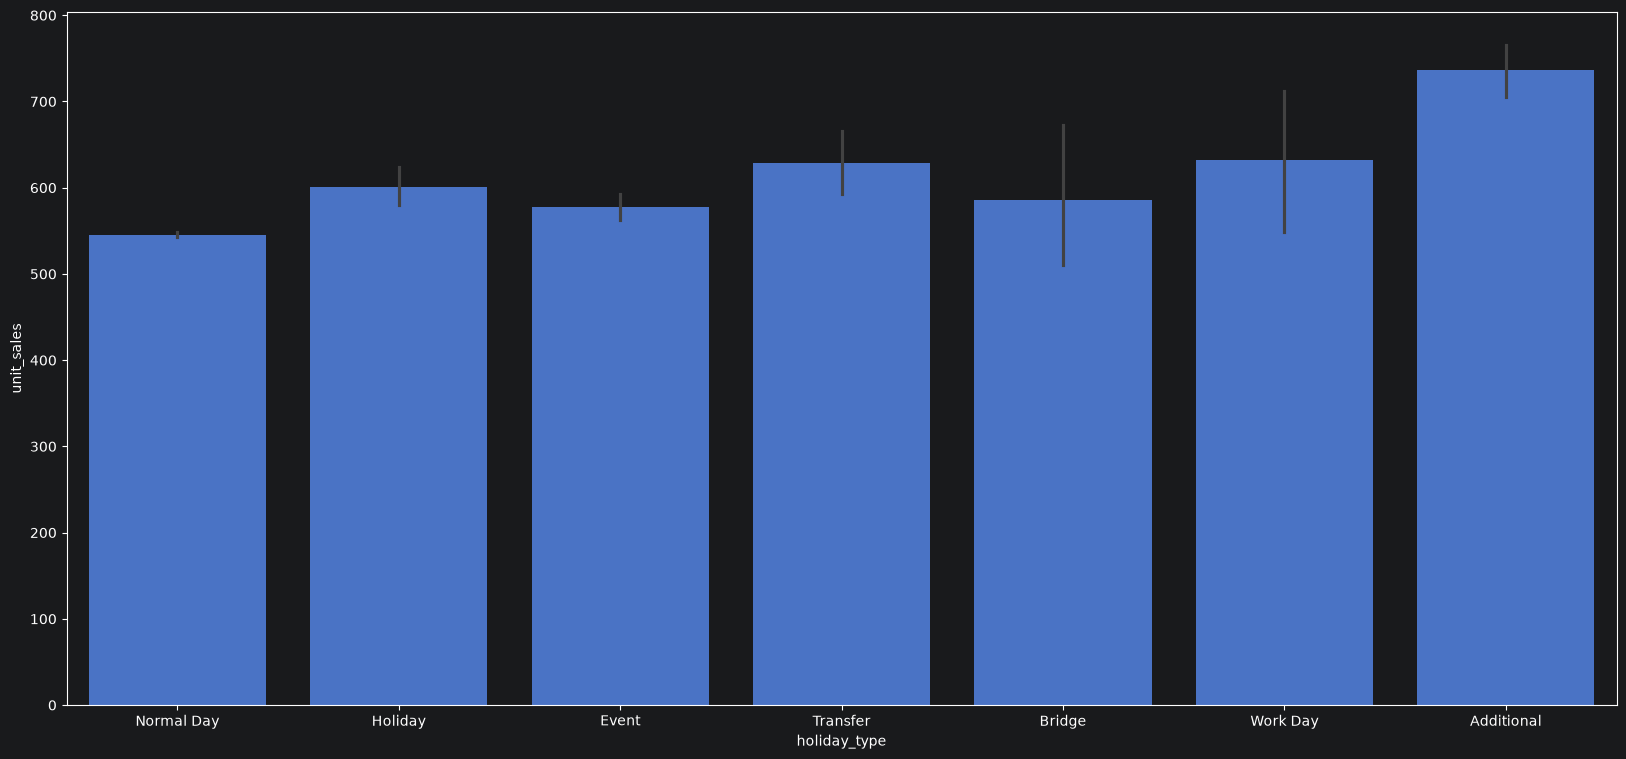

In [29]:
plt.figure(figsize=(20,9))
sns.barplot(data=train, x = 'holiday_type', y= 'unit_sales')

<Axes: xlabel='family', ylabel='unit_sales'>

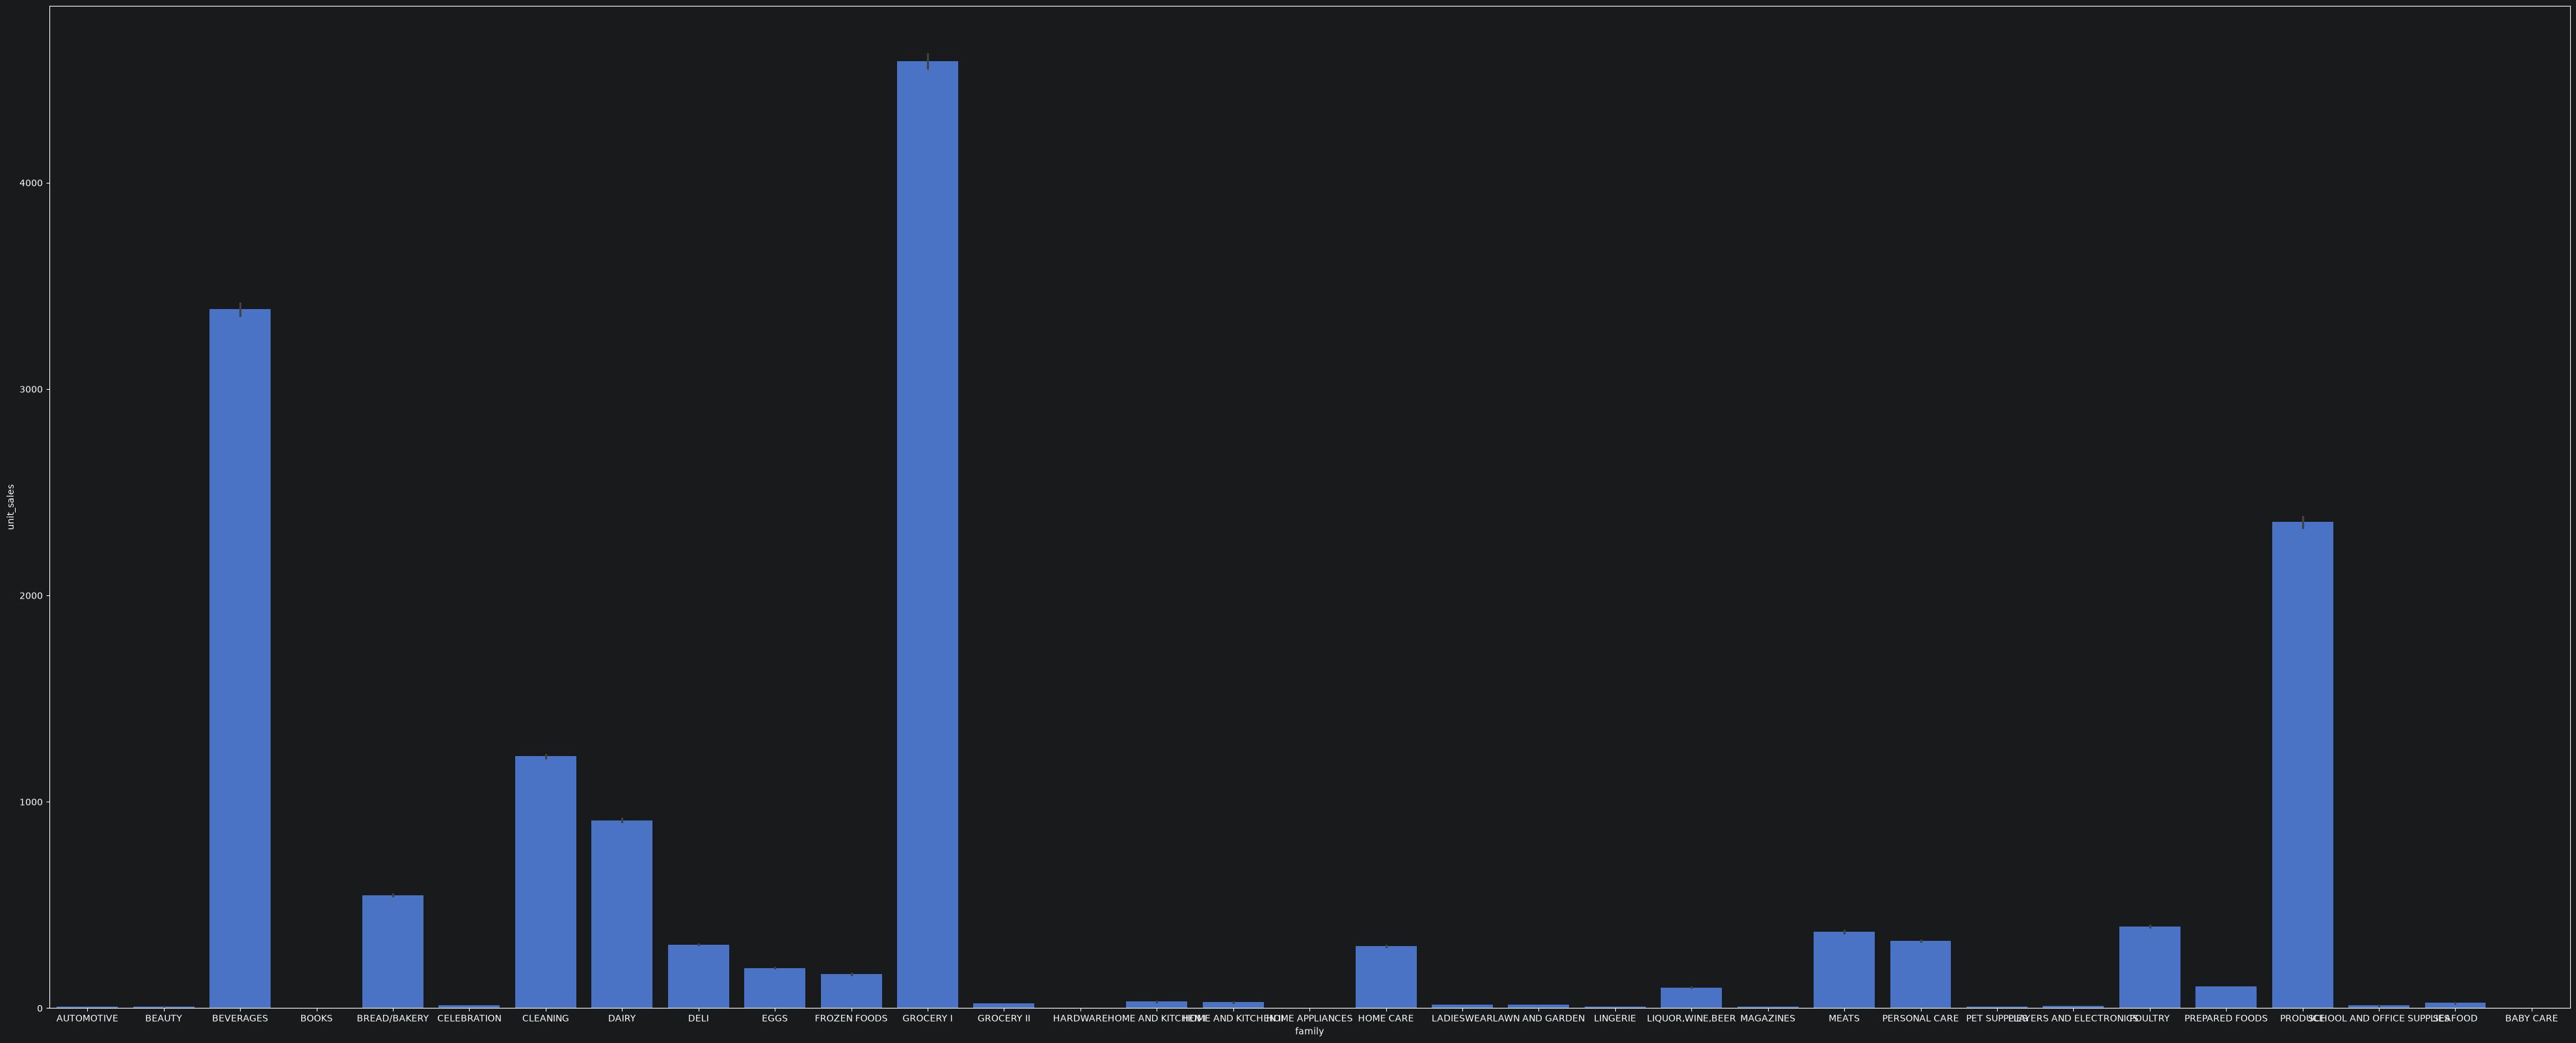

In [30]:
plt.figure(figsize=(50,20))
sns.barplot(data=train, x = 'family', y= 'unit_sales')

In [31]:
train.family.unique()

array(['AUTOMOTIVE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY',
       'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS',
       'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I',
       'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE',
       'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER',
       'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES',
       'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE',
       'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD', 'BABY CARE'], dtype=object)

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 874052 entries, 0 to 874051
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   store_nbr             874052 non-null  int8          
 1   family                874052 non-null  object        
 2   date                  874052 non-null  datetime64[ns]
 3   unit_sales            874052 non-null  float32       
 4   onpromotion           874052 non-null  boolean       
 5   oil_price             874052 non-null  float64       
 6   is_earthquake_period  874052 non-null  bool          
 7   holiday_type          874052 non-null  object        
 8   city                  874052 non-null  object        
 9   state                 874052 non-null  object        
 10  type                  874052 non-null  object        
 11  cluster               874052 non-null  int64         
 12  perishable            874052 non-null  int64         
 13 

# cac cot can encode: family, holiday_type, city, state, onpromotion, is_earthquake_period

ordinal:

In [33]:
train.store_nbr.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54], dtype=int8)

In [34]:
train.unit_sales.unique()

array([  7.     ,   1.     ,   8.     , ..., 696.92   , 877.304  ,
       915.37103], shape=(182131,), dtype=float32)

In [35]:
event = pd.read_csv('../data/raw/holidays_events.csv')
event = event[event.date>'2017-07-18']

In [36]:
event['date'] = pd.to_datetime(event['date'])
train[(train['date'] == '2017-07-24') & (train['city'] == 'Cayambe')]

,store_nbr,family,date,unit_sales,onpromotion,oil_price,is_earthquake_period,holiday_type,city,state,type,cluster,perishable,transactions_lag1,target
172577,11,AUTOMOTIVE,2017-07-24,8.000000,False,46.21,False,Normal Day,Cayambe,Pichincha,B,6,0,2213.0,8.000000
173336,11,BEAUTY,2017-07-24,3.000000,False,46.21,False,Normal Day,Cayambe,Pichincha,B,6,0,2213.0,3.000000
173926,11,BEVERAGES,2017-07-24,4149.000000,True,46.21,False,Normal Day,Cayambe,Pichincha,B,6,0,2213.0,4149.000000
174516,11,BREAD/BAKERY,2017-07-24,679.000000,True,46.21,False,Normal Day,Cayambe,Pichincha,B,6,1,2213.0,679.000000
175106,11,CELEBRATION,2017-07-24,6.000000,False,46.21,False,Normal Day,Cayambe,Pichincha,B,6,0,2213.0,6.000000
175696,11,CLEANING,2017-07-24,1826.000000,True,46.21,False,Normal Day,Cayambe,Pichincha,B,6,0,2213.0,1826.000000
176286,11,DAIRY,2017-07-24,679.000000,True,46.21,False,Normal Day,Cayambe,Pichincha,B,6,1,2213.0,679.000000
176876,11,DELI,2017-07-24,559.046021,True,46.21,False,Normal Day,Cayambe,Pichincha,B,6,1,2213.0,559.046021
177466,11,EGGS,2017-07-24,324.000000,True,46.21,False,Normal Day,Cayambe,Pichincha,B,6,1,2213.0,324.000000
178056,11,FROZEN FOODS,2017-07-24,77.393997,True,46.21,False,Normal Day,Cayambe,Pichincha,B,6,0,2213.0,77.393997


In [37]:
event.head(10)

,date,type,locale,locale_name,description,transferred
320,2017-07-23,Holiday,Local,Cayambe,Cantonizacion de Cayambe,False
321,2017-07-24,Additional,Local,Guayaquil,Fundacion de Guayaquil-1,False
322,2017-07-25,Additional,Local,Guayaquil,Fundacion de Guayaquil,False
323,2017-08-05,Holiday,Local,Esmeraldas,Fundacion de Esmeraldas,False
324,2017-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True
325,2017-08-11,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False
326,2017-08-15,Holiday,Local,Riobamba,Fundacion de Riobamba,False
327,2017-08-24,Holiday,Local,Ambato,Fundacion de Ambato,False
328,2017-09-28,Holiday,Local,Ibarra,Fundacion de Ibarra,True
329,2017-09-29,Transfer,Local,Ibarra,Fundacion de Ibarra,False


In [38]:
val3 = train[(train['date'] >= '2017-07-19') & (train['date'] <= '2017-08-15')]
print(val3.groupby('date').size())  # xem có ngày nào ít dòng bất thường không

date
2017-07-19    1491
2017-07-20    1506
2017-07-21    1501
2017-07-22    1534
2017-07-23    1544
2017-07-24    1527
2017-07-25    1513
2017-07-26    1496
2017-07-27    1505
2017-07-28    1506
2017-07-29    1521
2017-07-30    1541
2017-07-31    1529
2017-08-01    1525
2017-08-02    1519
2017-08-03    1510
2017-08-04    1508
2017-08-05    1534
2017-08-06    1544
2017-08-07    1510
2017-08-08    1523
2017-08-09    1517
2017-08-10    1501
2017-08-11    1533
2017-08-12    1533
2017-08-13    1537
2017-08-14    1513
2017-08-15    1521
dtype: int64


In [39]:
train.date.max()

Timestamp('2017-08-15 00:00:00')